In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from prepare_data import load_and_prepare
from model import RandomForest

In [4]:
X_train, X_test, y_train, y_test, feature_metadata, _ = load_and_prepare(csv_path="weatherAUS.csv")

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=43, stratify=y_train
)

# Собственная реализация

### Grid Search

In [5]:
from model import RandomForest, DecisionTree
from grid_search import GridSearchEstimator

param_grid = {
    "n_algorithms": [10, 30, 50, 100],
    "max_depth": [3, 5, 10],
    "criterion": ["gini", "entropy"],
}

search = GridSearchEstimator(
    estimator_class=RandomForest,
    param_grid=param_grid,
    fixed_params={"base_model_class": DecisionTree},
)

search.fit(X_tr.to_numpy(), y_tr)

print(search.best_params_)
print(search.best_score_)
best_model = search.best_estimator_

{'criterion': 'entropy', 'max_depth': 10, 'n_algorithms': 30}
0.815009083982887


In [7]:
search.results_

[GridSearchResult(params={'criterion': 'gini', 'max_depth': 3, 'n_algorithms': 10}, score=np.float64(0.7964691718638983)),
 GridSearchResult(params={'criterion': 'gini', 'max_depth': 3, 'n_algorithms': 30}, score=np.float64(0.7938717302545468)),
 GridSearchResult(params={'criterion': 'gini', 'max_depth': 3, 'n_algorithms': 50}, score=np.float64(0.8005137822579069)),
 GridSearchResult(params={'criterion': 'gini', 'max_depth': 3, 'n_algorithms': 100}, score=np.float64(0.7912149094532028)),
 GridSearchResult(params={'criterion': 'gini', 'max_depth': 5, 'n_algorithms': 10}, score=np.float64(0.7972799589427765)),
 GridSearchResult(params={'criterion': 'gini', 'max_depth': 5, 'n_algorithms': 30}, score=np.float64(0.7966848346324406)),
 GridSearchResult(params={'criterion': 'gini', 'max_depth': 5, 'n_algorithms': 50}, score=np.float64(0.8112387426986266)),
 GridSearchResult(params={'criterion': 'gini', 'max_depth': 5, 'n_algorithms': 100}, score=np.float64(0.8025650042001211)),
 GridSearchRes

##

In [10]:
feature_importances = best_model.get_feature_importance(X_tr.to_numpy(), y_tr)

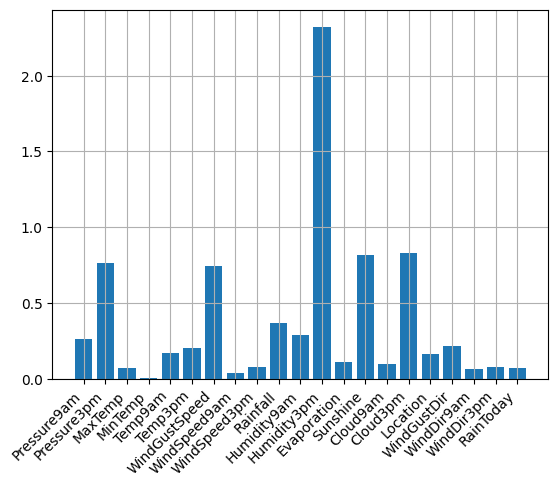

In [11]:
import matplotlib.pyplot as plt
import numpy as np

plt.bar(X_tr.columns, np.abs(feature_importances))
plt.xticks(rotation=45, ha='right')
plt.grid()
plt.show()

### Оценка метрик

In [29]:
y_pred = np.round(best_model.predict(X_test.to_numpy()))
acc_after = accuracy_score(y_test, y_pred)
f1_after = f1_score(y_test, y_pred, average="weighted")
precision_after = precision_score(y_test, y_pred)
recall_after = recall_score(y_test, y_pred)

print("  Accuracy:", acc_after)
print("  F1 (weighted):", f1_after)
print("  Precision:", precision_after)
print("  Recall:", recall_after)
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

  Accuracy: 0.8168711980027427
  F1 (weighted): 0.769349044749298
  Precision: 0.8882235528942116
  Recall: 0.20941176470588235
Confusion matrix:
 [[21896   168]
 [ 5040  1335]]


# Реализация sklearn

In [12]:
sklearn_model = RandomForestClassifier(n_estimators=30, criterion='entropy', max_depth=10, oob_score=True)

In [13]:
sklearn_model.fit(X_tr.to_numpy(), y_tr)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",30
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [14]:
sklearn_model.oob_score_

0.8474476938404736

In [21]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    sklearn_model,
    X_val.to_numpy(),
    y_val,
    scoring="accuracy",
    n_repeats=20,
    random_state=42,
)

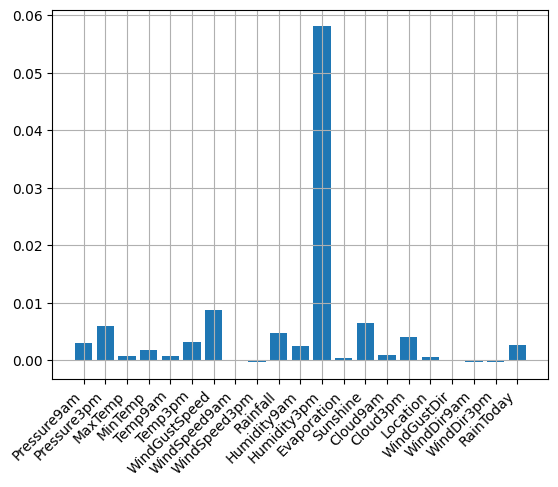

In [30]:
plt.bar(X_tr.columns, result['importances_mean'].flatten())
plt.xticks(rotation=45, ha='right')
plt.grid()
plt.show()


### Оценка метрик

In [33]:
y_pred = sklearn_model.predict(X_test.to_numpy())
acc_after = accuracy_score(y_test, y_pred)
f1_after = f1_score(y_test, y_pred, average="weighted")
precision_after = precision_score(y_test, y_pred)
recall_after = recall_score(y_test, y_pred)

print("  Accuracy:", acc_after)
print("  F1 (weighted):", f1_after)
print("  Precision:", precision_after)
print("  Recall:", recall_after)
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

  Accuracy: 0.8497485846900383
  F1 (weighted): 0.8348011178999476
  Precision: 0.7773087071240106
  Recall: 0.4621176470588235
Confusion matrix:
 [[21220   844]
 [ 3429  2946]]
